<a href="https://colab.research.google.com/github/MarcosRigal/AP/blob/main/adapted_performance_metrics_for_oc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Síntesis del Paper: Adapting performance metrics for ordinal classifcation to interval scale: length matters

En este cuaderno se explica la adaptación de las métricas para **clasificación ordinal** cuando las clases se definen como **intervalos** de longitudes potencialmente desiguales.

## 1. Función para dibujar la Matriz de Confusión

Dibujamos la matriz de confusión como un *heatmap*, para así visualizar fácilmente los aciertos y errores del clasificador.

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import random

def plot_confusion_matrix(cm, classes, title='Matriz de Confusión', normalize=False):
    """
    Dibuja un mapa de calor con la matriz de confusión.
    - cm: Matriz de confusión (numpy array) de tamaño [r, r].
    - classes: Lista o tupla con los nombres (etiquetas) de las clases.
    - title: Título de la figura.
    - normalize: Si es True, normaliza la matriz por filas.
    """
    plt.figure()
    if normalize:
        cm_sum = cm.sum(axis=1, keepdims=True)
        cm_sum[cm_sum == 0] = 1
        cm = cm / cm_sum

    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center", color="black")

    plt.ylabel('Clase Predicha')
    plt.xlabel('Clase Real')
    plt.tight_layout()
    plt.show()

## 2. Funciones para métricas Ordinales y Adaptadas a Intervalos

A continuación, definimos:
- **MAE (Mean Absolute Error)** en su versión ordinal.
- **TC (Total Misclassification Cost)** en su versión ordinal.
- **MAE_int** y **TC_int**, sus versiones adaptadas a intervalos, usando la "distancia entre intervalos" (ejemplo: distancia de Hausdorff) y la densidad (número de instancias dividido entre la longitud del intervalo).

Además, incluimos funciones auxiliares para:
- Calcular la distancia entre intervalos (`dist_interval`).
- Normalizar una métrica dividiéndola por su valor máximo posible.
- Calcular el valor máximo (MAE_max, TC_max) según la teoría del paper.
- Explorar la longitud óptima para el intervalo derecho abierto.

In [ ]:
def mae_ordinal(cm):
    """
    MAE (Mean Absolute Error) para clasificación ordinal.
    Asume que las clases están indexadas 0,1,...,r-1
    y la distancia entre clases es |i-j|.
    """
    N = cm.sum()
    if N == 0:
        return 0.0
    r = cm.shape[0]
    total_error = 0.0
    for i in range(r):
        for j in range(r):
            total_error += cm[i,j] * abs(i-j)
    return total_error / N

def tc_ordinal(cm, n):
    """
    TC (Total Misclassification Cost) versión ordinal.
    - cm: matriz de confusión.
    - n: array con la cantidad total de instancias verdaderas en cada clase.
    El coste = ((N - n[j]) / n[i]) * |i-j| para i!=j.
    """
    N = cm.sum()
    if N == 0:
        return 0.0
    r = cm.shape[0]
    total_cost = 0.0
    for i in range(r):
        for j in range(r):
            if i != j:
                cost_ij = ( (N - n[j]) / n[i] ) * abs(i-j)
                total_cost += cm[i,j] * cost_ij
    return total_cost

def dist_interval(i, j, lengths):
    """
    Función de ejemplo para la distancia entre intervalos I_i e I_j.
    Suponemos que:
       I_0 = [0, lengths[0]), I_1 = [lengths[0], lengths[0]+lengths[1]), etc.
    Simplificamos usando la suma de las longitudes intermedias.
    """
    if i == j:
        return 0.0
    if i > j:
        i, j = j, i
    return sum(lengths[i+1:j+1])

def mae_interval(cm, lengths):
    """
    MAE_int: versión de MAE que usa la distancia real entre intervalos.
    """
    N = cm.sum()
    if N == 0:
        return 0.0
    r = cm.shape[0]
    total_error = 0.0
    for i in range(r):
        for j in range(r):
            d = dist_interval(i, j, lengths)
            total_error += cm[i,j] * d
    return total_error / N

def tc_interval(cm, n, lengths):
    """
    TC_int: versión de TC adaptada a intervalos.
    Reemplaza n_j por densidad (n_j / lengths[j]) y |i-j| por dist_interval(i,j),
    según las ideas del paper.
    """
    N = cm.sum()
    if N == 0:
        return 0.0
    r = cm.shape[0]
    total_cost = 0.0

    dens = np.array([n[j] / lengths[j] for j in range(r)])

    for i in range(r):
        for j in range(r):
            if i != j:
                cost_ij = (dens.sum() - dens[j]) / dens[i]
                d = dist_interval(i, j, lengths)
                total_cost += cm[i,j] * cost_ij * d
    return total_cost

def normalize_metric(value, max_value):
    """
    Normaliza una métrica para que sea un valor en [0,1],
    dividiéndola entre su valor máximo posible (max_value).
    """
    if max_value == 0:
        return 0.0
    return value / max_value

def mae_max_ordinal(n):
    """
    Cálculo exacto de MAE_max (escala ordinal) usando la idea del paper:
    Buscar la matriz de confusión que maximiza el MAE (todas las instancias se
    asignan a la clase más lejana a la real, por columnas).
    """
    N = sum(n)
    r = len(n)
    # Para cada clase j, la peor predicción es la i que maximiza |i-j|
    # j e i en [0, r-1].
    # Valor: sum_{j=0..r-1} [n_j * max(|i-j|)] / N
    # i* es la clase que más se aleja de j.
    # Distancia ordinal = |i-j|.
    mae_max = 0.0
    for j in range(r):
        dist = [abs(i-j) for i in range(r)]
        max_dist = max(dist)
        mae_max += n[j] * max_dist
    return mae_max / N

def tc_max_ordinal(n):
    """
    Cálculo exacto de TC_max (escala ordinal)
    siguiendo la misma lógica de la matriz que maximiza el coste total.
    Para la clase j, la peor predicción es i que maximiza ((N - n_j)/n_i)*|i-j|.
    Sin embargo, n_i depende de i. Se debe escoger i^* que maximize el coste.
    Se asume que toda la col j se asigna a i^*.
    """
    N = sum(n)
    r = len(n)

    total_cost = 0.0
    for j in range(r):
        best_cost = 0.0
        for i in range(r):
            if i != j:
                c = ((N - n[j]) / n[i]) * abs(i-j)
                if c > best_cost:
                    best_cost = c
        total_cost += n[j] * best_cost
    return total_cost

def optimize_length_rightmost_interval(n, lengths_fixed, r_index=2, search_max=10.0, step=0.01, metric='TC'):
    """
    Cuando el intervalo derecho (rightmost interval) está abierto, podemos asignar
    una longitud x que minimize el valor máximo de la métrica adaptada (según el paper).
    Aquí, se hace un barrido discreto de x en [0.01..search_max] en pasos step.

    - n: array con el número de instancias en cada intervalo (excepto el último que irá en la posición r_index).
    - lengths_fixed: lista/array con las longitudes de todos los intervalos, menos la del último, que se variará.
    - r_index: índice del intervalo derecho (por defecto, 2 en un caso con 3 clases).
    - search_max: cota superior para x.
    - step: tamaño del paso.
    - metric: 'TC' o 'MAE'.
    Devuelve: (xmin, Mmax(xmin)).
    """
    r = len(n)

    def calc_metric_max(x):
        """
        Calcula M_int_max(x) = valor máximo de la métrica adaptada a intervalos.
        Para simplificar, emulamos la misma lógica de la peor confusión posible.
        """
        new_lengths = list(lengths_fixed)
        new_lengths[r_index] = x
        if metric == 'MAE':
            # "peor" asignación: para cada clase j, eliges la i que maximize la distancia de intervalos.
            # i.e. sum_{j} n_j * max_{i} dist_interval(i, j, new_lengths) / N.
            # Omitimos aquí la parte de "densidad" (porque no afecta en MAE).
            N_ = sum(n)
            sum_val = 0
            for j_ in range(r):
                max_d = 0
                for i_ in range(r):
                    d_ = dist_interval(i_, j_, new_lengths)
                    if d_ > max_d:
                        max_d = d_
                sum_val += n[j_] * max_d
            return sum_val / N_ if N_>0 else 0
        else:
            N_ = sum(n)
            dens = [n[k]/new_lengths[k] for k in range(r)]
            sum_val = 0
            for j_ in range(r):
                worst = 0
                for i_ in range(r):
                    if i_ != j_:
                        cost_ij = ((sum(dens) - dens[j_]) / dens[i_]) * dist_interval(i_, j_, new_lengths)
                        if cost_ij > worst:
                            worst = cost_ij
                sum_val += n[j_]*worst
            return sum_val

    best_x = 0.01
    best_val = calc_metric_max(best_x)
    x_ = best_x + step
    while x_ <= search_max:
        val = calc_metric_max(x_)
        if val < best_val:
            best_val = val
            best_x = x_
        x_ += step

    return best_x, best_val

## 3. Ejemplo con datos simulados

En esta sección, creamos una matriz de confusión de manera aleatoria (o parcialmente aleatoria), la visualizamos, y calculamos las distintas métricas (ordinales e interval-scale).

Cantidad de instancias verdaderas en cada clase (n): [11  8 17 19]
Total de instancias (N): 55

Matriz de confusión simulada (sin normalizar):
 [[10  4 10  3]
 [ 1  1  2  7]
 [ 0  2  4  7]
 [ 0  1  1  2]]


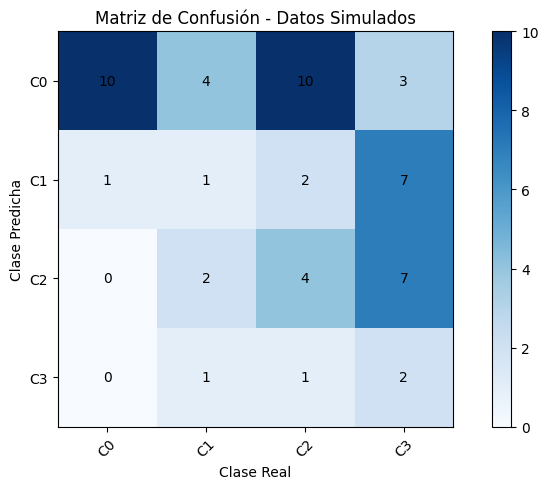

Longitudes de intervalos: [1.47633271 0.58461737 1.58299816 1.90782906]

MAE (ordinal) = 1.1273
TC (ordinal)  = 220.9367
MAE_int       = 1.5699
TC_int        = 280.9366


In [ ]:
r = 4
n_sim = np.random.randint(5, 20, size=r)
N_sim = sum(n_sim)
print("Cantidad de instancias verdaderas en cada clase (n):", n_sim)
print("Total de instancias (N):", N_sim)

cm_sim = np.zeros((r, r), dtype=int)
for j in range(r):
    remaining = n_sim[j]
    for i in range(r-1):
        val = np.random.randint(0, remaining+1)
        cm_sim[i, j] = val
        remaining -= val
    cm_sim[r-1, j] = remaining

print("\nMatriz de confusión simulada (sin normalizar):\n", cm_sim)
plot_confusion_matrix(cm_sim, classes=[f"C{i}" for i in range(r)],
                      title="Matriz de Confusión - Datos Simulados")

lengths_sim = np.random.uniform(0.5, 2.0, size=r)
print("Longitudes de intervalos:", lengths_sim)

mae_o = mae_ordinal(cm_sim)
tc_o = tc_ordinal(cm_sim, n_sim)

mae_i = mae_interval(cm_sim, lengths_sim)
tc_i = tc_interval(cm_sim, n_sim, lengths_sim)

print(f"\nMAE (ordinal) = {mae_o:.4f}")
print(f"TC (ordinal)  = {tc_o:.4f}")
print(f"MAE_int       = {mae_i:.4f}")
print(f"TC_int        = {tc_i:.4f}")

### 3.1 Cálculo exacto de valores máximos (MAE_max y TC_max)

De acuerdo con la teoría, podemos estimar el valor máximo de MAE y TC en la escala ordinal.
Para las versiones interval-scale, incluimos un ejemplo de "peor caso" (no siempre trivial),
pero en este cuaderno mostramos la idea principal: comparar el valor observado con el valor máximo.

In [ ]:
mae_o_max = mae_max_ordinal(n_sim)
tc_o_max = tc_max_ordinal(n_sim)

print(f"\nMAE_ordinal_max teórico = {mae_o_max:.4f}")
print(f"TC_ordinal_max teórico = {tc_o_max:.4f}")

mae_o_norm = normalize_metric(mae_o, mae_o_max)
tc_o_norm = normalize_metric(tc_o, tc_o_max)
print(f"\nMAE (ordinal) normalizado = {mae_o_norm:.4f}")
print(f"TC (ordinal)  normalizado = {tc_o_norm:.4f}")


MAE_ordinal_max teórico = 2.5455
TC_ordinal_max teórico = 420.0000

MAE (ordinal) normalizado = 0.4429
TC (ordinal)  normalizado = 0.5260


## 4. Ejemplo: intervalo derecho no acotado

Supongamos que tenemos 3 clases-intervalos: \(I_1, I_2, I_3\), con \(I_3\) no acotado a la derecha.

In [ ]:
r_3 = 3
n_3 = np.array([5, 7, 4])
print("n (casos en cada intervalo):", n_3)

lengths_fixed_3 = [1.0, 0.4, 1.0]

xmin_mae, mmax_mae = optimize_length_rightmost_interval(
    n=n_3,
    lengths_fixed=lengths_fixed_3,
    r_index=2,
    search_max=5.0,
    step=0.01,
    metric='MAE'
)

print("\n[MAE] Longitud óptima para el intervalo derecho =", xmin_mae)
print("Valor MAE_int_max con esa longitud =", mmax_mae)

xmin_tc, mmax_tc = optimize_length_rightmost_interval(
    n=n_3,
    lengths_fixed=lengths_fixed_3,
    r_index=2,
    search_max=5.0,
    step=0.01,
    metric='TC'
)

print("\n[TC] Longitud óptima para el intervalo derecho =", xmin_tc)
print("Valor TC_int_max con esa longitud =", mmax_tc)

n (casos en cada intervalo): [5 7 4]

[MAE] Longitud óptima para el intervalo derecho = 0.01
Valor MAE_int_max con esa longitud = 0.405625

[TC] Longitud óptima para el intervalo derecho = 0.23000000000000007
Valor TC_int_max con esa longitud = 30.198817934782607
